In [8]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [9]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games_enriched.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

print(f"Loaded {len(df):,} games")

Loaded 82,107 games


In [10]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

df["release_quarter"] = (
    df["release_date"]
      .dt.to_period("Q")
      .astype(str)
)

for c in ["positive","negative","price"]:
    df[c] = (
        pd.to_numeric(df[c], errors="coerce")
        .fillna(0)
    )

df["total_reviews"] = (
    df["positive"] +
    df["negative"]
)

REVIEW_MULTIPLIER = 45

df["estimated_revenue"] = (
    df["total_reviews"]
    * REVIEW_MULTIPLIER
    * df["price"]
)

df["ai_disclosed"] = (
    df["ai_disclosed"]
    .fillna(False)
    .astype(bool)
)

In [11]:
def normalize_tags(value):

    if isinstance(value, dict):
        return list(value.keys())

    if isinstance(value, list):
        return value

    if isinstance(value, str):

        try:
            parsed = ast.literal_eval(value)

            if isinstance(parsed, dict):
                return list(parsed.keys())

            if isinstance(parsed, list):
                return parsed

        except Exception:
            pass

    return []


df["tag_list"] = (
    df["tags"]
    .apply(normalize_tags)
)

df["is_indie"] = (
    df["tag_list"]
    .apply(
        lambda tags:
        any(
            t.lower()=="indie"
            for t in tags
        )
    )
)

In [12]:
START_DATE = "2024-01-01"
END_DATE = "2025-12-31"

analysis = (
    df[
        df["release_date"].between(
            START_DATE,
            END_DATE,
            inclusive="both"
        )
    ]
    .copy()
)

print(
    f"Analysis period: {START_DATE} → {END_DATE}"
)
print(
    f"Games in analysis: {len(analysis):,}"
)

Analysis period: 2024-01-01 → 2025-12-31
Games in analysis: 39,691


In [13]:
# ------------------------------------------------------------
# Calculate AI-disclosure share for each cohort, quarter by quarter
# ------------------------------------------------------------

COHORT_ORDER = [
    "All games",
    "Top 1000 by revenue",
    "Top 100 by revenue",
    "Indie games",
    "$150K–$800K revenue band",
]

rows = []

for quarter, quarter_games in analysis.groupby(
    "release_quarter",
    sort=True
):
    quarter_games = quarter_games.copy()

    # Top revenue cohorts are selected independently within each quarter
    cohorts = {
        "All games": quarter_games,

        "Top 1000 by revenue": quarter_games.nlargest(
            min(1000, len(quarter_games)),
            "estimated_revenue"
        ),

        "Top 100 by revenue": quarter_games.nlargest(
            min(100, len(quarter_games)),
            "estimated_revenue"
        ),

        "Indie games": quarter_games.loc[
            quarter_games["is_indie"]
        ],

        "$150K–$800K revenue band": quarter_games.loc[
            quarter_games["estimated_revenue"].between(
                150_000,
                800_000,
                inclusive="both"
            )
        ],
    }

    for cohort_name, cohort_data in cohorts.items():

        total_games = len(cohort_data)

        if total_games == 0:
            ai_games = 0
            ai_share = np.nan
        else:
            ai_games = int(
                cohort_data["ai_disclosed"].sum()
            )

            ai_share = (
                100
                * ai_games
                / total_games
            )

        rows.append({
            "release_quarter": quarter,
            "cohort": cohort_name,
            "total_games": total_games,
            "ai_disclosed_games": ai_games,
            "ai_disclosed_share": ai_share,
        })

ai_summary = pd.DataFrame(rows)

ai_summary["cohort"] = pd.Categorical(
    ai_summary["cohort"],
    categories=COHORT_ORDER,
    ordered=True
)

ai_summary = ai_summary.sort_values(
    ["release_quarter", "cohort"]
).reset_index(drop=True)

display(
    ai_summary.style.format({
        "total_games": "{:,.0f}",
        "ai_disclosed_games": "{:,.0f}",
        "ai_disclosed_share": "{:.1f}%"
    }).hide(axis="index")
)

release_quarter,cohort,total_games,ai_disclosed_games,ai_disclosed_share
2024Q1,All games,"3,939",282,7.2%
2024Q1,Top 1000 by revenue,"1,000",50,5.0%
2024Q1,Top 100 by revenue,100,5,5.0%
2024Q1,Indie games,"1,349",81,6.0%
2024Q1,$150K–$800K revenue band,121,7,5.8%
2024Q2,All games,"4,263",481,11.3%
2024Q2,Top 1000 by revenue,"1,000",67,6.7%
2024Q2,Top 100 by revenue,100,4,4.0%
2024Q2,Indie games,"1,417",146,10.3%
2024Q2,$150K–$800K revenue band,144,7,4.9%


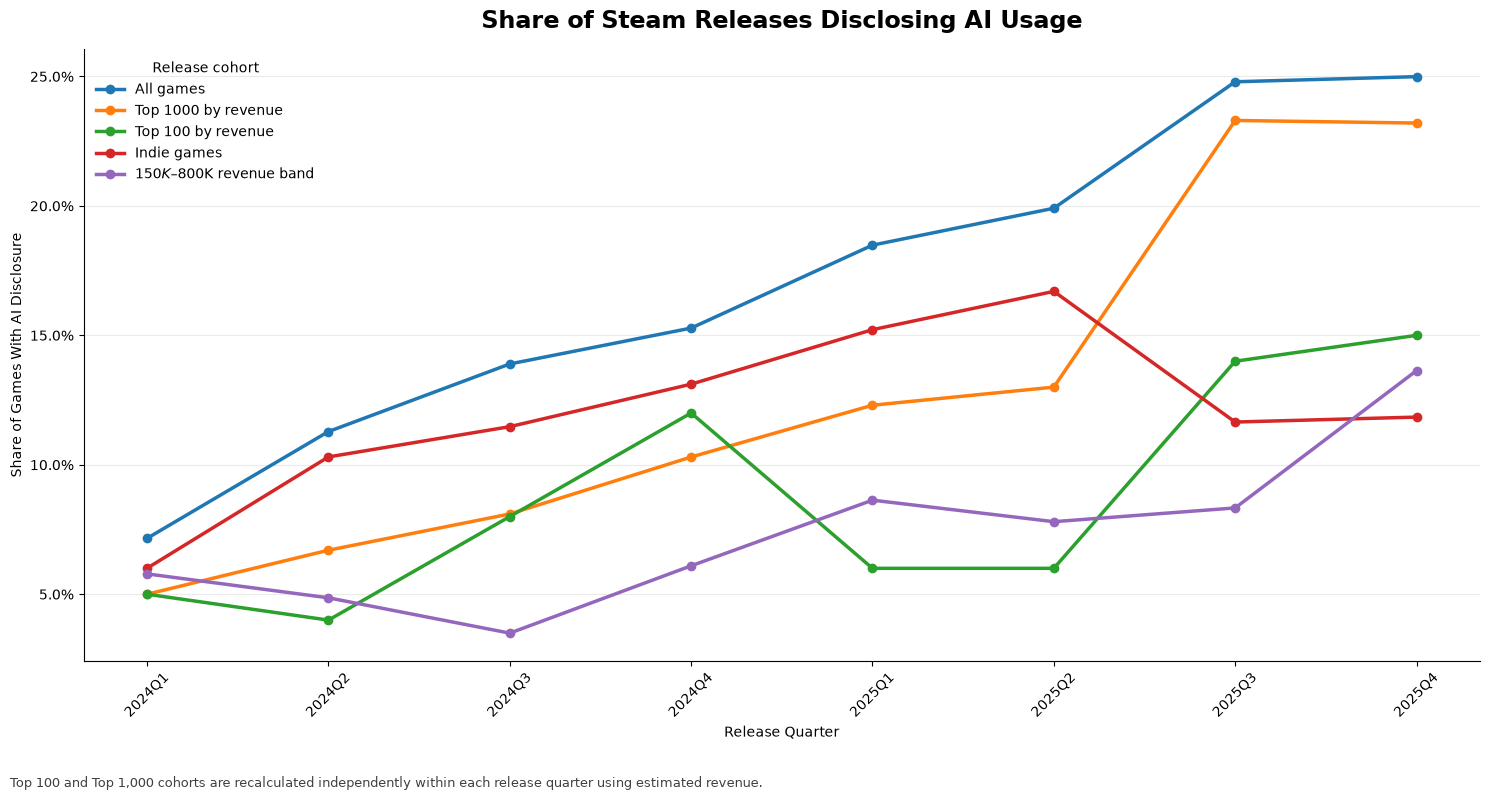

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(15, 8))

for cohort_name in COHORT_ORDER:

    cohort_data = ai_summary.loc[
        ai_summary["cohort"] == cohort_name
    ].sort_values("release_quarter")

    ax.plot(
        cohort_data["release_quarter"],
        cohort_data["ai_disclosed_share"],
        marker="o",
        linewidth=2.5,
        label=cohort_name
    )

ax.set_title(
    "Share of Steam Releases Disclosing AI Usage",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Quarter")
ax.set_ylabel("Share of Games With AI Disclosure")

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.legend(
    title="Release cohort",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Top 100 and Top 1,000 cohorts are recalculated independently "
        "within each release quarter using estimated revenue."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [19]:
analysis = df[
    df["release_date"].between(
        "2024-01-01",
        "2025-12-31"
    )
].copy()

# ------------------------------------------------------------
# Review score
# ------------------------------------------------------------

analysis["total_reviews"] = (
    analysis["positive"] +
    analysis["negative"]
)

analysis = analysis.loc[
    analysis["total_reviews"] > 0
].copy()

analysis["review_score"] = (
    100
    * analysis["positive"]
    / analysis["total_reviews"]
)

# ------------------------------------------------------------
# Revenue buckets
# ------------------------------------------------------------

REVENUE_BINS = [
    0,
    10_000,
    50_000,
    150_000,
    800_000,
    5_000_000,
    np.inf
]

REVENUE_LABELS = [
    "<$10K",
    "$10K–50K",
    "$50K–150K",
    "$150K–800K",
    "$800K–5M",
    ">$5M"
]

analysis["revenue_bucket"] = pd.cut(
    analysis["estimated_revenue"],
    bins=REVENUE_BINS,
    labels=REVENUE_LABELS,
    include_lowest=True
)

In [20]:
summary = (
    analysis
    .groupby(
        ["revenue_bucket", "ai_disclosed"],
        observed=True
    )
    .agg(
        games=("appid", "count"),
        median_review_score=("review_score", "median"),
        mean_review_score=("review_score", "mean"),
        median_reviews=("total_reviews", "median"),
        median_revenue=("estimated_revenue", "median")
    )
    .reset_index()
)

display(
    summary.style.format({
        "games":"{:,.0f}",
        "median_review_score":"{:.1f}%",
        "mean_review_score":"{:.1f}%",
        "median_reviews":"{:,.0f}",
        "median_revenue":"${:,.0f}"
    })
)

,revenue_bucket,ai_disclosed,games,median_review_score,mean_review_score,median_reviews,median_revenue
0,<$10K,False,"11,695",94.4%,81.7%,6,$725
1,<$10K,True,"1,910",90.0%,77.8%,5,$585
2,$10K–50K,False,"2,007",87.7%,84.0%,73,"$20,844"
3,$10K–50K,True,218,83.2%,80.4%,68,"$18,060"
4,$50K–150K,False,890,86.1%,83.4%,216,"$82,637"
5,$50K–150K,True,81,84.3%,81.8%,320,"$92,502"
6,$150K–800K,False,841,86.6%,83.9%,650,"$289,032"
7,$150K–800K,True,57,83.8%,80.4%,582,"$274,484"
8,$800K–5M,False,376,87.4%,84.2%,"2,856","$1,626,473"
9,$800K–5M,True,25,87.4%,82.5%,"2,783","$1,482,370"


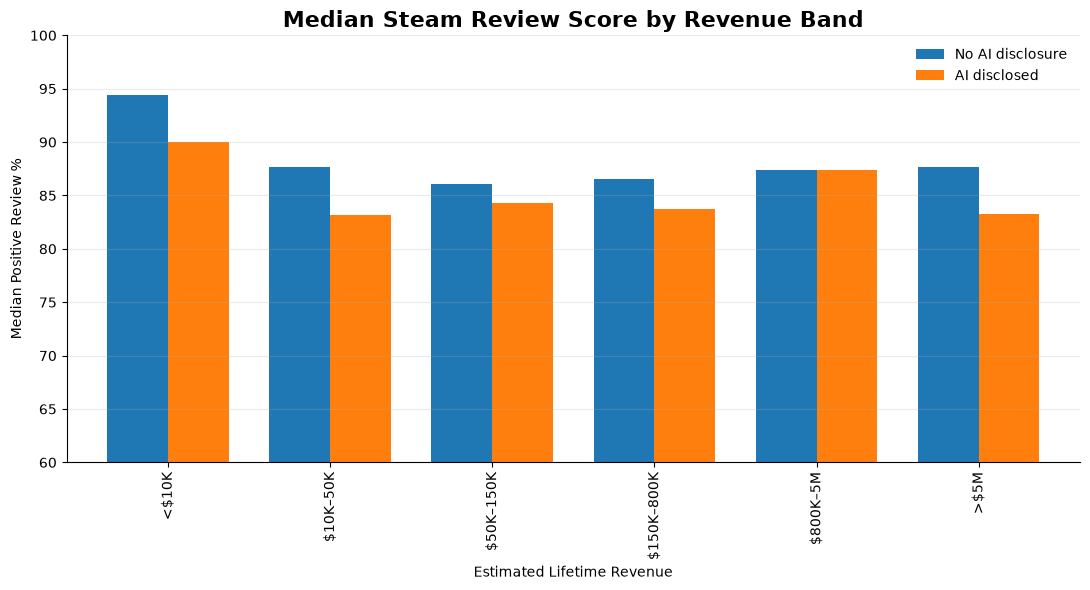

In [21]:
plot_data = (
    summary.pivot(
        index="revenue_bucket",
        columns="ai_disclosed",
        values="median_review_score"
    )
)

plot_data = plot_data.rename(
    columns={
        False:"No AI disclosure",
        True:"AI disclosed"
    }
)

fig, ax = plt.subplots(figsize=(11,6))

plot_data.plot(
    kind="bar",
    ax=ax,
    width=0.75
)

ax.set_title(
    "Median Steam Review Score by Revenue Band",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Estimated Lifetime Revenue")
ax.set_ylabel("Median Positive Review %")

ax.set_ylim(60,100)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [22]:
counts = (
    summary
    .pivot(
        index="revenue_bucket",
        columns="ai_disclosed",
        values="games"
    )
)

display(counts)

ai_disclosed,False,True
revenue_bucket,,
<$10K,11695,1910
$10K–50K,2007,218
$50K–150K,890,81
$150K–800K,841,57
$800K–5M,376,25
>$5M,197,12


In [23]:
REVENUE_BUCKETS_TO_KEEP = [
    "$50K–150K",
    "$150K–800K",
    "$800K–5M",
    ">$5M"
]

quarterly_reviews = (
    analysis[
        analysis["revenue_bucket"].isin(
            REVENUE_BUCKETS_TO_KEEP
        )
    ]
    .groupby(
        [
            "release_quarter",
            "revenue_bucket",
            "ai_disclosed"
        ],
        observed=True
    )
    .agg(
        games=("appid", "count"),
        median_review_score=("review_score", "median"),
        mean_review_score=("review_score", "mean")
    )
    .reset_index()
)

display(quarterly_reviews.head())

,release_quarter,revenue_bucket,ai_disclosed,games,median_review_score,mean_review_score
0,2024Q1,$50K–150K,False,129,85.967742,81.636730
1,2024Q1,$50K–150K,True,6,91.014030,91.132995
2,2024Q1,$150K–800K,False,114,84.917361,81.545821
3,2024Q1,$150K–800K,True,7,84.495192,82.700710
4,2024Q1,$800K–5M,False,53,85.918491,84.039299


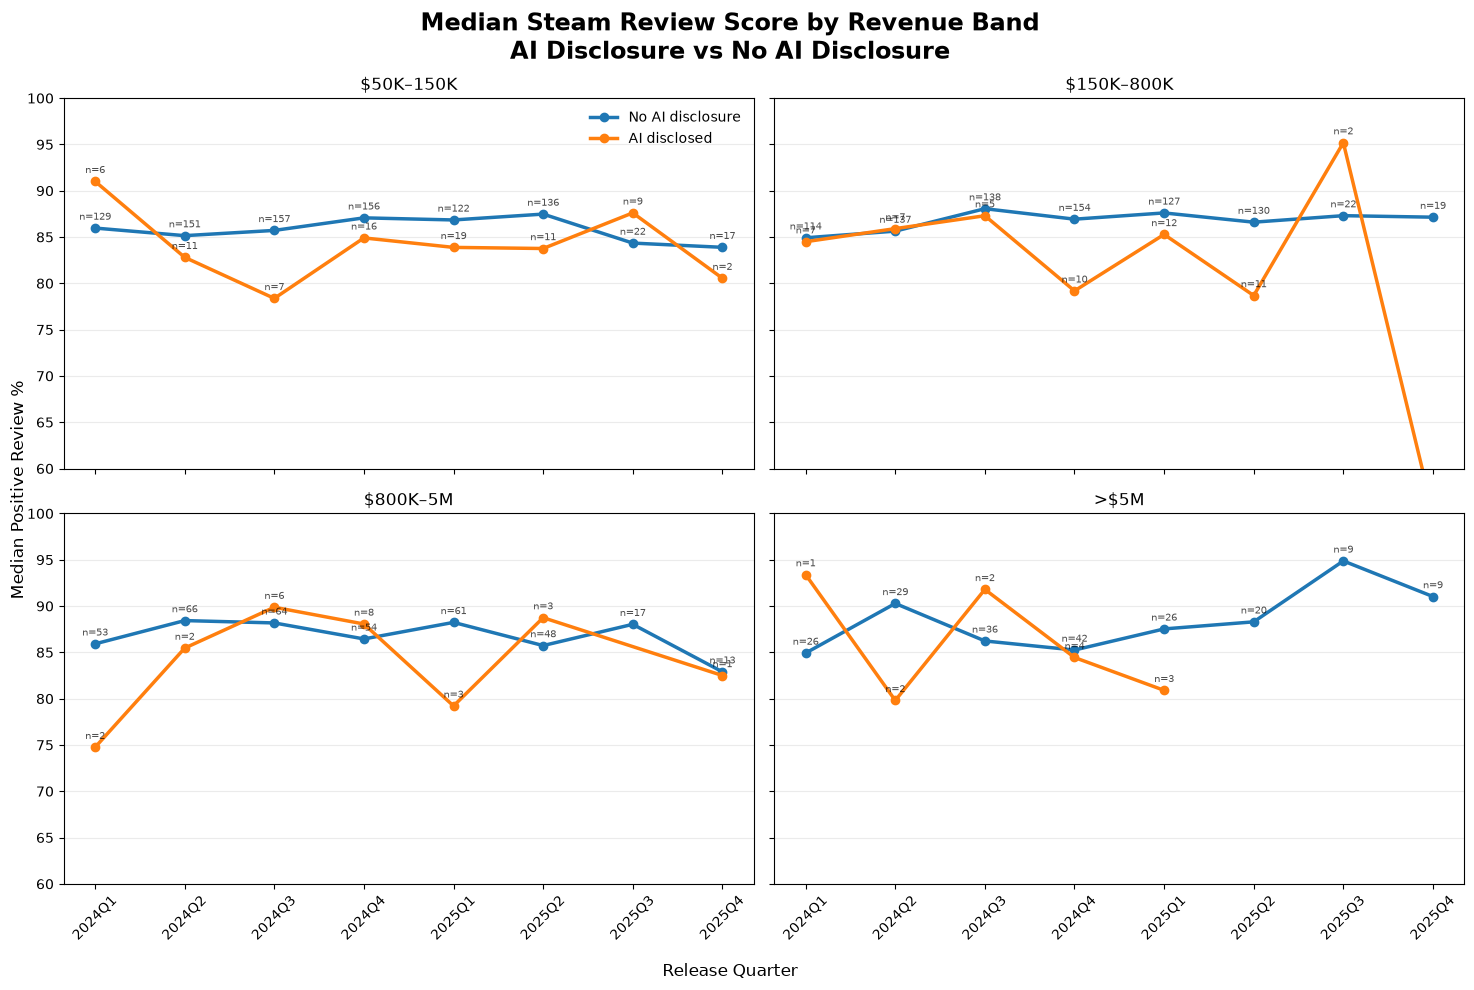

In [24]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15,10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, bucket in zip(
    axes,
    REVENUE_BUCKETS_TO_KEEP
):

    bucket_data = quarterly_reviews[
        quarterly_reviews["revenue_bucket"] == bucket
    ]

    for disclosed, label in [
        (False, "No AI disclosure"),
        (True, "AI disclosed")
    ]:

        subset = bucket_data[
            bucket_data["ai_disclosed"] == disclosed
        ].sort_values("release_quarter")

        ax.plot(
            subset["release_quarter"],
            subset["median_review_score"],
            marker="o",
            linewidth=2.5,
            label=label
        )

        # annotate sample size
        for _, row in subset.iterrows():
            ax.annotate(
                f"n={int(row['games'])}",
                (
                    row["release_quarter"],
                    row["median_review_score"]
                ),
                xytext=(0,6),
                textcoords="offset points",
                ha="center",
                fontsize=7,
                alpha=0.7
            )

    ax.set_title(bucket)

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.set_ylim(60,100)

axes[0].legend(
    frameon=False
)

fig.suptitle(
    "Median Steam Review Score by Revenue Band\nAI Disclosure vs No AI Disclosure",
    fontsize=17,
    weight="bold"
)

fig.supxlabel("Release Quarter")
fig.supylabel("Median Positive Review %")

plt.tight_layout()

plt.show()

In [25]:
MIN_REVENUE = 50_000
MIN_GAMES_PER_GROUP = 5

ai_review_analysis = df.loc[
    df["release_date"].between(
        "2024-01-01",
        "2025-12-31",
        inclusive="both"
    )
    & df["estimated_revenue"].ge(MIN_REVENUE)
    & df["total_reviews"].gt(0)
].copy()

# Recreate this safely in case the column does not already exist
ai_review_analysis["release_quarter"] = (
    ai_review_analysis["release_date"]
    .dt.to_period("Q")
)

ai_review_analysis["review_score"] = (
    100
    * ai_review_analysis["positive"]
    / ai_review_analysis["total_reviews"]
)

ai_review_analysis["ai_group"] = np.where(
    ai_review_analysis["ai_disclosed"],
    "AI disclosed",
    "No AI disclosure"
)

quarterly_ai_reviews = (
    ai_review_analysis
    .groupby(
        ["release_quarter", "ai_group"],
        observed=True
    )
    .agg(
        games=("appid", "nunique"),
        median_review_score=("review_score", "median"),
        mean_review_score=("review_score", "mean"),
        median_reviews=("total_reviews", "median"),
        median_revenue=("estimated_revenue", "median")
    )
    .reset_index()
)

# Hide statistically fragile quarter/group observations
quarterly_ai_reviews["plot_score"] = (
    quarterly_ai_reviews["median_review_score"]
    .where(
        quarterly_ai_reviews["games"] >= MIN_GAMES_PER_GROUP
    )
)

quarterly_ai_reviews["quarter_label"] = (
    quarterly_ai_reviews["release_quarter"]
    .astype(str)
)

display(
    quarterly_ai_reviews.style.format({
        "games": "{:,.0f}",
        "median_review_score": "{:.1f}%",
        "mean_review_score": "{:.1f}%",
        "plot_score": "{:.1f}%",
        "median_reviews": "{:,.0f}",
        "median_revenue": "${:,.0f}"
    }).hide(axis="index")
)

release_quarter,ai_group,games,median_review_score,mean_review_score,median_reviews,median_revenue,plot_score,quarter_label
2024Q1,AI disclosed,16,86.6%,85.5%,742,"$268,844",86.6%,2024Q1
2024Q1,No AI disclosure,322,85.5%,81.7%,725,"$210,973",85.5%,2024Q1
2024Q2,AI disclosed,22,84.7%,81.0%,454,"$147,979",84.7%,2024Q2
2024Q2,No AI disclosure,383,86.0%,83.3%,575,"$243,337",86.0%,2024Q2
2024Q3,AI disclosed,20,86.4%,81.9%,891,"$559,827",86.4%,2024Q3
2024Q3,No AI disclosure,395,87.1%,84.1%,550,"$217,769",87.1%,2024Q3
2024Q4,AI disclosed,38,87.4%,82.3%,587,"$249,713",87.4%,2024Q4
2024Q4,No AI disclosure,406,86.9%,84.2%,536,"$222,712",86.9%,2024Q4
2025Q1,AI disclosed,37,80.9%,80.4%,484,"$137,592",80.9%,2025Q1
2025Q1,No AI disclosure,336,87.5%,84.7%,508,"$229,199",87.5%,2025Q1


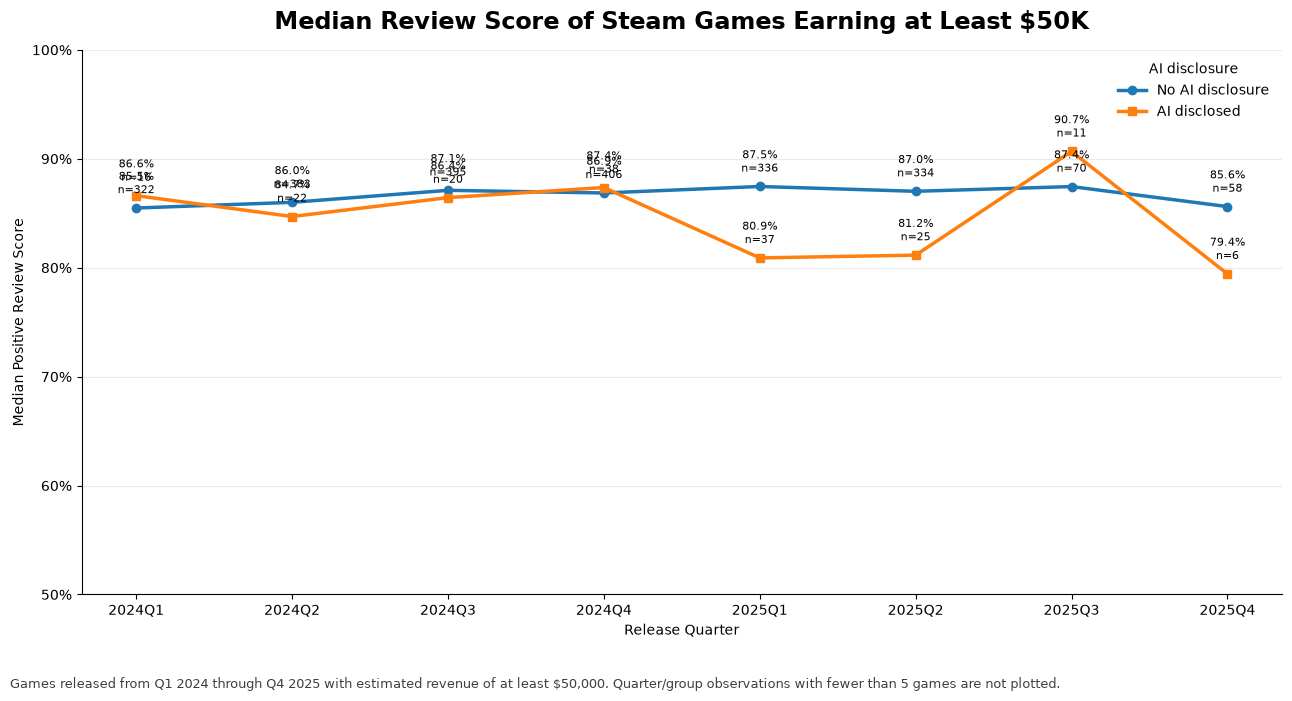

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

QUARTER_ORDER = [
    str(quarter)
    for quarter in pd.period_range(
        "2024Q1",
        "2025Q4",
        freq="Q"
    )
]

fig, ax = plt.subplots(figsize=(13, 7))

for group_name, marker in [
    ("No AI disclosure", "o"),
    ("AI disclosed", "s")
]:
    group_data = (
        quarterly_ai_reviews.loc[
            quarterly_ai_reviews["ai_group"] == group_name
        ]
        .set_index("quarter_label")
        .reindex(QUARTER_ORDER)
        .reset_index()
    )

    ax.plot(
        group_data["quarter_label"],
        group_data["plot_score"],
        marker=marker,
        linewidth=2.5,
        label=group_name
    )

    for _, row in group_data.iterrows():
        if pd.notna(row["plot_score"]):
            ax.annotate(
                (
                    f'{row["plot_score"]:.1f}%\n'
                    f'n={int(row["games"]):,}'
                ),
                xy=(
                    row["quarter_label"],
                    row["plot_score"]
                ),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

ax.set_title(
    "Median Review Score of Steam Games Earning at Least $50K",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Quarter")
ax.set_ylabel("Median Positive Review Score")

ax.set_ylim(50, 100)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.legend(
    title="AI disclosure",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Games released from Q1 2024 through Q4 2025 with estimated "
        f"revenue of at least ${MIN_REVENUE:,.0f}. "
        f"Quarter/group observations with fewer than "
        f"{MIN_GAMES_PER_GROUP} games are not plotted."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()